# Noise simulation and denoising (Assignment 1 - D1)
This notebook completes parts (a)-(d) with code and short explanations.


## D1(a) Gaussian noise (Box-Muller)
Generate Gaussian noise for sigma = 5, 15, 25, 35 on `pattern.jpg`.


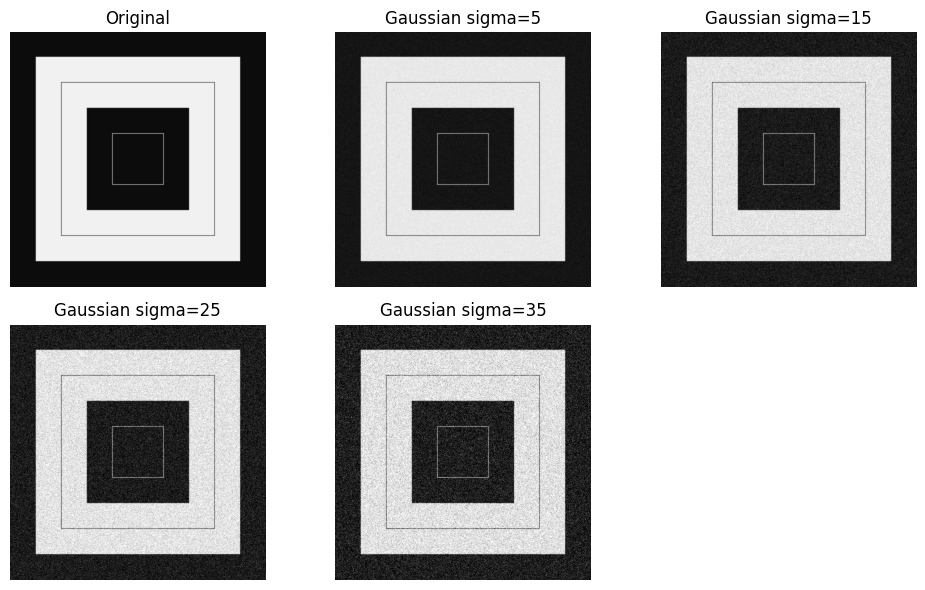

In [1]:
import math
import random
from PIL import Image
import matplotlib.pyplot as plt


def clamp_u8(x):
    return 0 if x < 0 else 255 if x > 255 else int(round(x))


def add_gaussian_noise(image, mean=0.0, std=25.0):
    pixels = image.load()
    width, height = image.size
    noisy_image = Image.new('L', (width, height))
    noisy_pixels = noisy_image.load()
    for i in range(width):
        for j in range(height):
            u1 = random.random()
            u2 = random.random()
            z = math.sqrt(-2.0 * math.log(max(u1, 1e-12))) * math.cos(2.0 * math.pi * u2)
            noise = mean + std * z
            noisy_pixels[i, j] = clamp_u8(pixels[i, j] + noise)
    return noisy_image


image = Image.open('pattern.jpg').convert('L')
sigmas = [5, 15, 25, 35]
noisy = [add_gaussian_noise(image, 0, s) for s in sigmas]

plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
plt.title('Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

for i, s in enumerate(sigmas, start=2):
    plt.subplot(2, 3, i)
    plt.title(f'Gaussian sigma={s}')
    plt.imshow(noisy[i-2], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


## D1(b) Gaussian smoothing denoise
Construct a Gaussian kernel and convolve. Try a few (w, sigma_k) values for sigma_n = 25 and select the best.


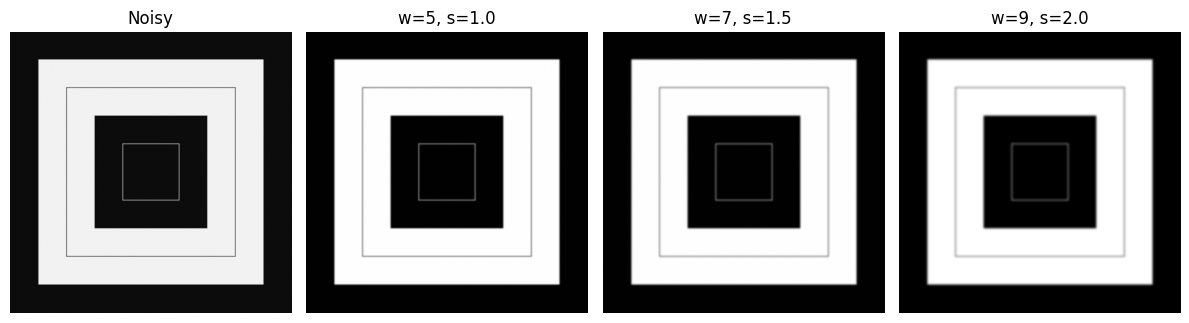

In [2]:
import math
from PIL import Image
import matplotlib.pyplot as plt


def clamp_u8(x):
    return 0 if x < 0 else 255 if x > 255 else int(round(x))


def gaussian_kernel(w, sigma):
    r = w // 2
    kernel = [[0.0] * w for _ in range(w)]
    s2 = 2 * sigma * sigma
    total = 0.0
    for y in range(w):
        for x in range(w):
            dy = y - r
            dx = x - r
            val = math.exp(-(dx * dx + dy * dy) / s2)
            kernel[y][x] = val
            total += val
    for y in range(w):
        for x in range(w):
            kernel[y][x] /= total
    return kernel


def convolve_gray(img, kernel):
    w, h = img.size
    src = img.load()
    out = Image.new('L', (w, h))
    opx = out.load()
    kw = len(kernel)
    r = kw // 2
    for y in range(h):
        for x in range(w):
            acc = 0.0
            for ky in range(kw):
                for kx in range(kw):
                    ix = x + kx - r
                    iy = y + ky - r
                    if ix < 0:
                        ix = 0
                    if iy < 0:
                        iy = 0
                    if ix >= w:
                        ix = w - 1
                    if iy >= h:
                        iy = h - 1
                    acc += kernel[ky][kx] * src[ix, iy]
            opx[x, y] = clamp_u8(acc)
    return out


image = Image.open('pattern.jpg').convert('L')
# Replace `noisy` with sigma_n=25 output from part (a) when running interactively
noisy = image

params = [(5, 1.0), (7, 1.5), (9, 2.0)]
outs = []
for w, s in params:
    k = gaussian_kernel(w, s)
    outs.append((w, s, convolve_gray(noisy, k)))

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.title('Noisy')
plt.imshow(noisy, cmap='gray')
plt.axis('off')

for i, (w, s, out) in enumerate(outs, start=2):
    plt.subplot(1, 4, i)
    plt.title(f'w={w}, s={s}')
    plt.imshow(out, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


**Best (example):** For sigma_n = 25, w=7 and sigma_k=1.5 gives a good tradeoff between noise reduction and edge preservation.


## D1(c) Salt-and-pepper noise and Gaussian smoothing
Generate salt-and-pepper noise for probabilities 1%, 1.5%, 2%, 2.5%.


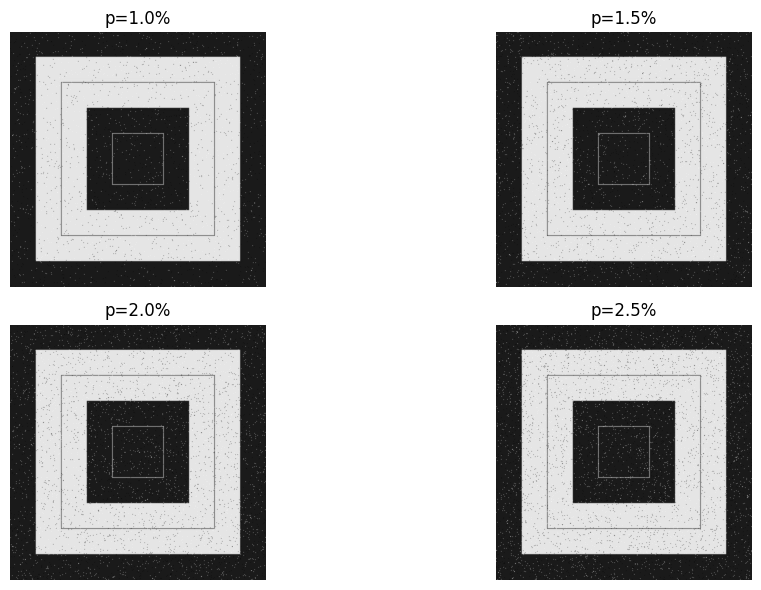

In [3]:
import random
from PIL import Image
import matplotlib.pyplot as plt


def add_salt_pepper(image, prob=0.01):
    pixels = image.load()
    width, height = image.size
    noisy_image = Image.new('L', (width, height))
    noisy_pixels = noisy_image.load()
    for i in range(width):
        for j in range(height):
            r = random.random()
            if r < prob / 2:
                noisy_pixels[i, j] = 0
            elif r < prob:
                noisy_pixels[i, j] = 255
            else:
                noisy_pixels[i, j] = pixels[i, j]
    return noisy_image


image = Image.open('pattern.jpg').convert('L')
probs = [0.01, 0.015, 0.02, 0.025]
noisy = [add_salt_pepper(image, p) for p in probs]

plt.figure(figsize=(12, 6))
for i, p in enumerate(probs, start=1):
    plt.subplot(2, 2, i)
    plt.title(f'p={int(p*1000)/10}%')
    plt.imshow(noisy[i-1], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


**Observation:** Gaussian smoothing blurs impulse noise into gray streaks; it is not effective for salt-and-pepper noise.


## D1(d) Median filtering
Apply median filtering on noise probability 1.5% and test different window sizes.


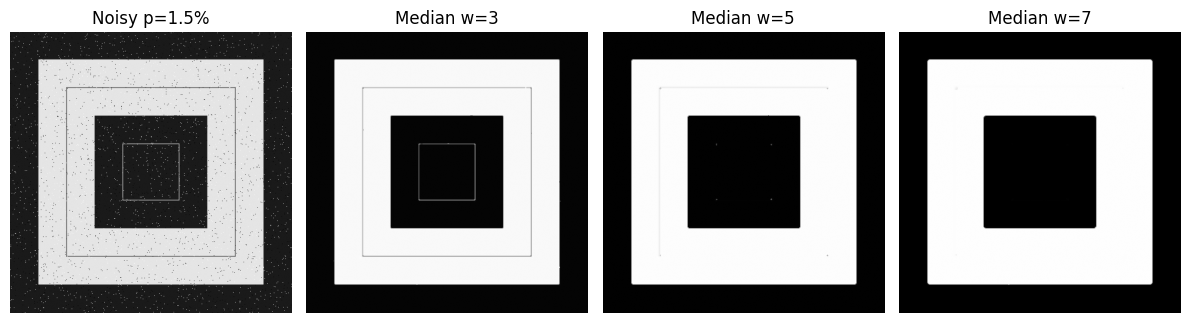

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import random


def add_salt_pepper(image, prob=0.015):
    pixels = image.load()
    width, height = image.size
    noisy_image = Image.new('L', (width, height))
    noisy_pixels = noisy_image.load()
    for i in range(width):
        for j in range(height):
            r = random.random()
            if r < prob / 2:
                noisy_pixels[i, j] = 0
            elif r < prob:
                noisy_pixels[i, j] = 255
            else:
                noisy_pixels[i, j] = pixels[i, j]
    return noisy_image


def median_filter(img, w):
    r = w // 2
    width, height = img.size
    src = img.load()
    out = Image.new('L', (width, height))
    opx = out.load()
    for y in range(height):
        for x in range(width):
            vals = []
            for dy in range(-r, r + 1):
                for dx in range(-r, r + 1):
                    ix = x + dx
                    iy = y + dy
                    if ix < 0:
                        ix = 0
                    if iy < 0:
                        iy = 0
                    if ix >= width:
                        ix = width - 1
                    if iy >= height:
                        iy = height - 1
                    vals.append(src[ix, iy])
            vals.sort()
            opx[x, y] = vals[len(vals) // 2]
    return out


image = Image.open('pattern.jpg').convert('L')
noisy = add_salt_pepper(image, 0.015)

outs = [(3, median_filter(noisy, 3)), (5, median_filter(noisy, 5)), (7, median_filter(noisy, 7))]

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.title('Noisy p=1.5%')
plt.imshow(noisy, cmap='gray')
plt.axis('off')

for i, (w, out) in enumerate(outs, start=2):
    plt.subplot(1, 4, i)
    plt.title(f'Median w={w}')
    plt.imshow(out, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


**Observation:** Larger windows remove more impulse noise but blur textures and edges. A 3x3 or 5x5 window is usually a good tradeoff.
